In [12]:
# # !pip install kagglehub

# import kagglehub
# kagglehub.competition_download('digit-recognizer')
!pip install tqdm

In [13]:
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data
from torch.autograd import Variable
from tqdm import tqdm

from sklearn.model_selection import train_test_split

In [14]:
import matplotlib.pyplot as plt
import math

%matplotlib inline

In [15]:
data_train = pd.read_csv("digit-recognizer/train.csv", dtype = np.float32)
print("Number of training:",data_train.shape[0])


Number of training: 42000


In [16]:
data_train.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [17]:
X = data_train.drop("label", axis=1).values/255
y = data_train["label"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)

In [18]:
def plot_sample_images(X, y, ncols=5, num=25):
    num = int(min(num, len(y)))
    nrows = math.ceil(num / ncols)
    fig, axes = plt.subplots(ncols=ncols, nrows=nrows, figsize=(ncols, nrows))
    fig.subplots_adjust(hspace=0.8)
    for i, ax in enumerate(axes.flatten()):
        if i < num:
            ax.imshow(X.max()-X[i].reshape(28, 28), cmap="gray")
            ax.set_title(str(y[i]))
        ax.axis('off')
    plt.show()

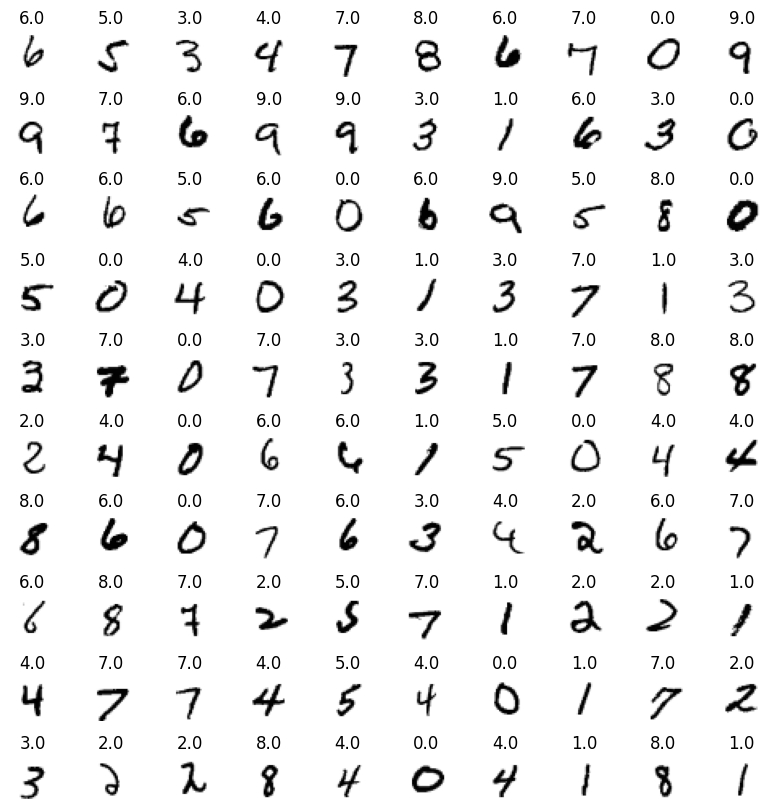

In [19]:
plot_sample_images(X_train, y_train, ncols=10, num=100)

In [20]:
import tensorflow as tf
print(tf.__version__)
print(tf.config.list_physical_devices())

2.20.0
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [21]:
from keras.models import Sequential
from keras.utils import to_categorical
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D, Input
from keras.optimizers import AdamW





model = Sequential([
    Conv2D(32, activation='relu', kernel_size=(5,5), padding='Same', input_shape = (28,28, 1)),
    Conv2D(32, activation='relu', kernel_size=(3,3), padding='Same'),    
    
    MaxPool2D(pool_size=(2,2)),

    Conv2D(64, activation='relu', kernel_size=(3,3), padding='Same'),
    
    
    Flatten(),
    Dense(256, activation="relu"),
    Dropout(0.33),
    Dense(10,activation="softmax")
])


model.compile(
    optimizer="adamW",
    loss="categorical_crossentropy",
    metrics="accuracy"
)

X_train_final = X_train.reshape(-1,28,28,1)
y_train_final  = to_categorical(y_train_final, 10)

X_test_final  = X_test.reshape(-1,28,28,1)
y_test_final  = to_categorical(y_test_final, 10)

history = model.fit(
    X_train_final, y_train_final,
    epochs=10,
    validation_data= (X_test_final, y_test_final),
    batch_size=150,
    verbose=1
)

/home/sutemou/code/mlka/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-03-11 03:12:39.656457: W tensorflow/compiler/mlir/tools/kernel_gen/tf_gpu_runtime_wrappers.cc:40] 'cuModuleLoadData(&module, data)' failed with 'CUDA_ERROR_INVALID_PTX'

2026-03-11 03:12:39.656472: W tensorflow/compiler/mlir/tools/kernel_gen/tf_gpu_runtime_wrappers.cc:40] 'cuModuleGetFunction(&function, module, kernel_name)' failed with 'CUDA_ERROR_INVALID_HANDLE'

2026-03-11 03:12:39.656481: W tensorflow/core/framework/op_kernel.cc:1842] INTERNAL: 'cuLaunchKernel(function, gridX, gridY, gridZ, blockX, blockY, blockZ, 0, reinterpret_cast<CUstream>(stream), params, nullptr)' failed with 'CUDA_ERROR_INVALID_HANDLE'
2026-03-11

InternalError: {{function_node __wrapped__Cast_device_/job:localhost/replica:0/task:0/device:GPU:0}} 'cuLaunchKernel(function, gridX, gridY, gridZ, blockX, blockY, blockZ, 0, reinterpret_cast<CUstream>(stream), params, nullptr)' failed with 'CUDA_ERROR_INVALID_HANDLE' [Op:Cast] name: 

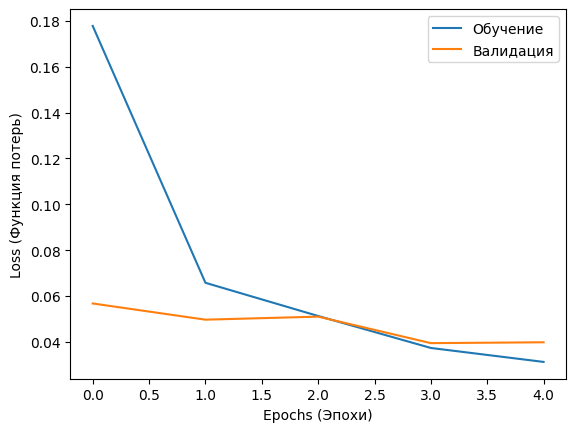

In [ ]:
# Графики обучения
plt.plot(history.history['loss'], label='Обучение')
plt.plot(history.history['val_loss'], label='Валидация')
plt.xlabel('Epochs (Эпохи)')
plt.ylabel('Loss (Функция потерь)')
plt.legend()
plt.show()

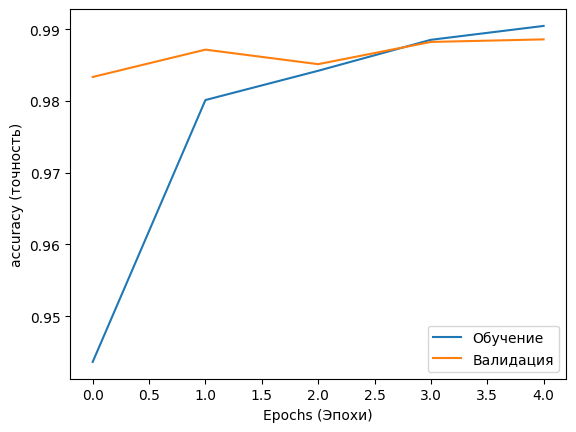

In [ ]:
plt.plot(history.history['accuracy'], label='Обучение')
plt.plot(history.history['val_accuracy'], label='Валидация')
plt.xlabel('Epochs (Эпохи)')
plt.ylabel('accuracy (точность)')
plt.legend()
plt.show()

In [ ]:
data_test = pd.read_csv("digit-recognizer/test.csv", dtype = np.float32)
print("Number of testing:",data_test.shape[0])


In [ ]:
X_actual_test = data_test.values / 255.0

X_actual_test = X_actual_test.reshape(-1, 28, 28, 1)

In [ ]:
predictions = model.predict(X_actual_test)

digits = np.argmax(predictions, axis=1)

In [ ]:
prophecy = pd.DataFrame({
    "ImageId": range(1, len(digits) + 1),
    "Label": digits
})